Primeiras linhas do dataset:
   idade  salario  tempo_cliente_anos  comprou
0     22     1800                   1        0
1     35     4500                   3        1
2     45     8000                   8        1
3     28     2200                   1        0
4     52     9500                  10        1
5     31     3200                   2        0
6     40     6000                   5        1
7     25     1500                   0        0
8     38     5500                   4        1
9     48     7800                   7        1

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   idade               50 non-null     int64
 1   salario             50 non-null     int64
 2   tempo_cliente_anos  50 non-null     int64
 3   comprou             50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB
None

Estatísticas

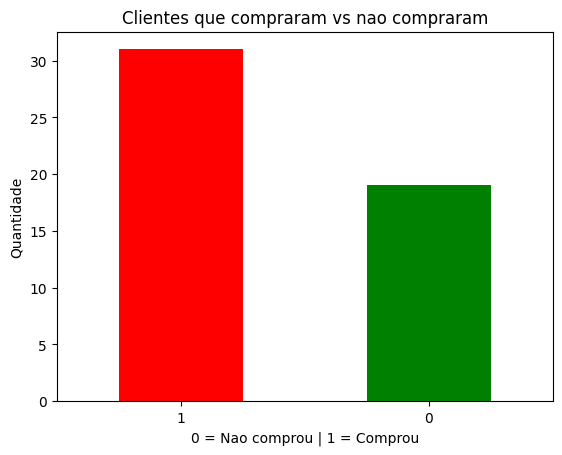


Correlacao com a variavel alvo:
comprou               1.000000
idade                 0.813442
salario               0.786143
tempo_cliente_anos    0.735688
Name: comprou, dtype: float64

Valores nulos:
idade                 0
salario               0
tempo_cliente_anos    0
comprou               0
dtype: int64

Shape de X: (50, 3)
Shape de y: (50,)

Dados normalizados (primeiras 3 linhas):
[[-1.56346481 -1.22042313 -1.05879101]
 [-0.38588413 -0.43361739 -0.60631622]
 [ 0.51994716  0.58631598  0.52487076]]

Tamanho treino: 40
Tamanho teste: 10

Modelos treinados!

=== RESULTADOS ===
Regressao Logistica: 100.0%
Arvore de Decisao:   100.0%
KNN:                 90.0%

Matriz de confusao - Arvore de Decisao:
[[4 0]
 [0 6]]


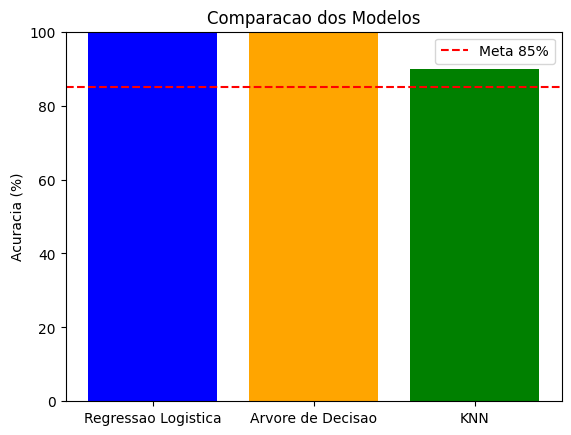


Modelo salvo!

Testando com cliente novo (35 anos, R$5000, 3 anos):
O modelo diz que o cliente VAI comprar!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

dados = {
    'idade': [22, 35, 45, 28, 52, 31, 40, 25, 38, 48,
              29, 55, 33, 41, 27, 50, 36, 43, 24, 58,
              30, 47, 26, 53, 39, 34, 46, 21, 60, 37,
              23, 44, 32, 57, 42, 28, 51, 35, 49, 26,
              38, 54, 29, 45, 33, 61, 27, 48, 36, 52],
    'salario': [1800, 4500, 8000, 2200, 9500, 3200, 6000, 1500, 5500, 7800,
                2800, 11000, 3800, 6500, 2000, 9000, 4200, 7000, 1600, 12000,
                3000, 8500, 1900, 10000, 5800, 4000, 8200, 1400, 13000, 4800,
                1700, 7200, 3500, 11500, 6800, 2500, 9800, 4600, 8800, 2100,
                5200, 10500, 3100, 7600, 3900, 14000, 2300, 9200, 4400, 10200],
    'tempo_cliente_anos': [1, 3, 8, 1, 10, 2, 5, 0, 4, 7,
                            2, 12, 3, 6, 1, 9, 4, 7, 0, 15,
                            2, 8, 1, 11, 5, 3, 8, 0, 16, 4,
                            1, 7, 3, 13, 6, 2, 10, 4, 9, 1,
                            5, 11, 2, 7, 3, 18, 1, 9, 4, 10],
    'comprou': [0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
                0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
                0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
                0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
                1, 1, 0, 1, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(dados)

print("Primeiras linhas do dataset:")
print(df.head(10))
print()
print("Informações:")
print(df.info())
print()
print("Estatísticas:")
print(df.describe())

print()
print("Quantos compraram e nao compraram:")
print(df['comprou'].value_counts())


df['comprou'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Clientes que compraram vs nao compraram')
plt.xlabel('0 = Nao comprou | 1 = Comprou')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.savefig('grafico_target.png')
plt.show()


print()
print("Correlacao com a variavel alvo:")
print(df.corr()['comprou'].sort_values(ascending=False))


print()
print("Valores nulos:")
print(df.isnull().sum())
# nao tem nenhum entao ta bom


X = df[['idade', 'salario', 'tempo_cliente_anos']].values
y = df['comprou'].values

print()
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print()
print("Dados normalizados (primeiras 3 linhas):")
print(X_scaled[:3])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                      test_size=0.2,
                                                      random_state=42)

print()
print("Tamanho treino:", X_train.shape[0])
print("Tamanho teste:", X_test.shape[0])


modelo1 = LogisticRegression()
modelo1.fit(X_train, y_train)


modelo2 = DecisionTreeClassifier(random_state=42)
modelo2.fit(X_train, y_train)


modelo3 = KNeighborsClassifier(n_neighbors=5)
modelo3.fit(X_train, y_train)

print()
print("Modelos treinados!")

pred1 = modelo1.predict(X_test)
pred2 = modelo2.predict(X_test)
pred3 = modelo3.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

print()
print("=== RESULTADOS ===")
print(f"Regressao Logistica: {acc1*100:.1f}%")
print(f"Arvore de Decisao:   {acc2*100:.1f}%")
print(f"KNN:                 {acc3*100:.1f}%")


print()
print("Matriz de confusao - Arvore de Decisao:")
print(confusion_matrix(y_test, pred2))


modelos_nomes = ['Regressao Logistica', 'Arvore de Decisao', 'KNN']
acuracias = [acc1*100, acc2*100, acc3*100]

plt.bar(modelos_nomes, acuracias, color=['blue', 'orange', 'green'])
plt.title('Comparacao dos Modelos')
plt.ylabel('Acuracia (%)')
plt.ylim(0, 100)
plt.axhline(y=85, color='red', linestyle='--', label='Meta 85%')
plt.legend()
plt.savefig('comparacao_modelos.png')
plt.show()


joblib.dump(modelo2, 'modelo_final.pkl')
print()
print("Modelo salvo!")


modelo_salvo = joblib.load('modelo_final.pkl')


cliente_novo = scaler.transform([[35, 5000, 3]])
resultado = modelo_salvo.predict(cliente_novo)

print()
print("Testando com cliente novo (35 anos, R$5000, 3 anos):")
if resultado[0] == 1:
    print("O modelo diz que o cliente VAI comprar!")
else:
    print("O modelo diz que o cliente NAO vai comprar.")